In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
train = pd.read_csv("../data/raw/train.csv")
stores = pd.read_csv("../data/raw/stores.csv")
features = pd.read_csv("../data/raw/features.csv")

In [6]:
merged_df=train.merge(stores, on='Store')
merged_df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,False,A,151315
1,1,1,2010-02-12,46039.49,True,A,151315
2,1,1,2010-02-19,41595.55,False,A,151315
3,1,1,2010-02-26,19403.54,False,A,151315
4,1,1,2010-03-05,21827.90,False,A,151315


In [11]:
final_merge=merged_df.merge(features,on=['Store','Date'],how='left')
final_merge.head()



,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [13]:
final_merge.shape

(421570, 17)

In [17]:
final_merge.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
 16  IsHoliday_y   421570 non-null  bool   
dtypes: bool(2), float64(10), int64(3), object(2)
mem

In [19]:
final_merge.isna().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday_x          0
Type                 0
Size                 0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
IsHoliday_y          0
dtype: int64

In [27]:
final_merge.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday_x   421570 non-null  bool   
 5   Type          421570 non-null  object 
 6   Size          421570 non-null  int64  
 7   Temperature   421570 non-null  float64
 8   Fuel_Price    421570 non-null  float64
 9   MarkDown1     150681 non-null  float64
 10  MarkDown2     111248 non-null  float64
 11  MarkDown3     137091 non-null  float64
 12  MarkDown4     134967 non-null  float64
 13  MarkDown5     151432 non-null  float64
 14  CPI           421570 non-null  float64
 15  Unemployment  421570 non-null  float64
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [35]:
final_merge["Store"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45])

In [37]:
final_merge["Store"].nunique()

45

In [39]:
final_merge["Dept"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 16, 17, 18,
       19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 40, 41, 42, 44, 45, 46, 47, 48, 49, 51, 52, 54, 55, 56,
       58, 59, 60, 67, 71, 72, 74, 77, 78, 79, 80, 81, 82, 83, 85, 87, 90,
       91, 92, 93, 94, 95, 96, 97, 98, 99, 39, 50, 43, 65])

In [41]:
final_merge["Dept"].nunique()

81

In [44]:
final_merge["Type"].unique()

array(['A', 'B', 'C'], dtype=object)

In [47]:
final_merge["Date"].nunique()

143

In [50]:
final_merge["Weekly_Sales"].sum()

np.float64(6737218987.110001)

In [54]:
pd.set_option("display.float_format", "{:,.2f}".format)
round(final_merge.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False),2)

Store
20   301,397,792.46
4    299,543,953.38
14   288,999,911.34
13   286,517,703.80
2    275,382,440.98
10   271,617,713.89
27   253,855,916.88
6    223,756,130.64
1    222,402,808.85
39   207,445,542.47
19   206,634,862.10
31   199,613,905.50
23   198,750,617.85
24   194,016,021.28
11   193,962,786.80
28   189,263,680.58
41   181,341,934.89
32   166,819,246.16
18   155,114,734.21
22   147,075,648.57
12   144,287,230.15
26   143,416,393.79
34   138,249,763.00
40   137,870,309.79
35   131,520,672.08
8    129,951,181.13
17   127,782,138.83
45   112,395,341.42
21   108,117,878.92
25   101,061,179.17
43    90,565,435.41
15    89,133,683.92
7     81,598,275.14
42    79,565,752.43
9     77,789,218.99
29    77,141,554.31
16    74,252,425.40
37    74,202,740.32
30    62,716,885.12
3     57,586,735.07
38    55,159,626.42
36    53,412,214.97
5     45,475,688.90
44    43,293,087.84
33    37,160,221.96
Name: Weekly_Sales, dtype: float64

In [56]:
final_merge.groupby("Type")["Weekly_Sales"].sum().sort_values(ascending=False)

Type
A   4,331,014,722.75
B   2,000,700,736.82
C     405,503,527.54
Name: Weekly_Sales, dtype: float64

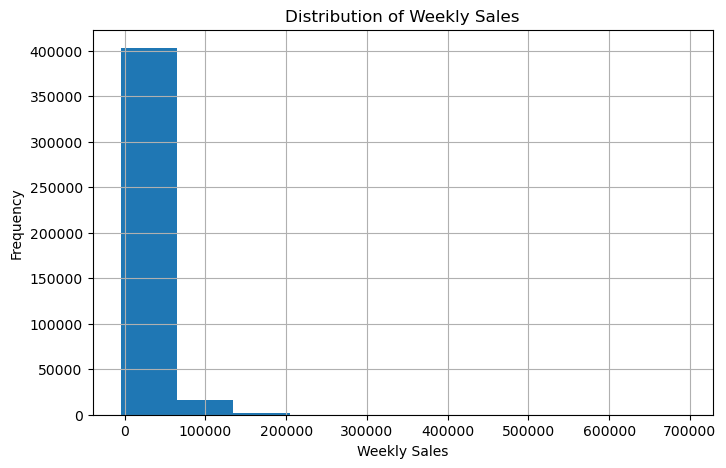

In [59]:
# data plot

final_merge["Weekly_Sales"].hist(figsize=(8,5))
plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

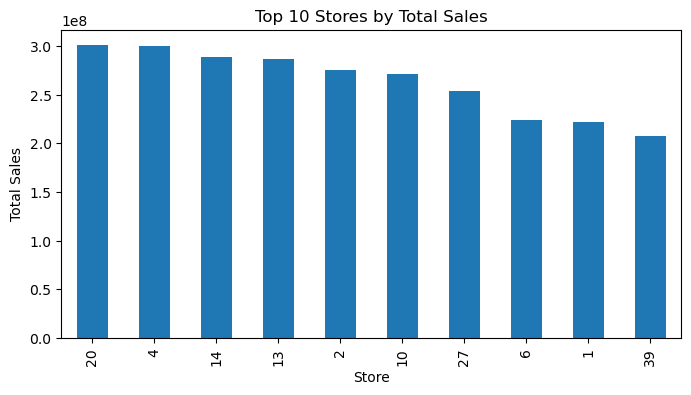

In [62]:
top10 = final_merge.groupby("Store")["Weekly_Sales"].sum().sort_values(ascending=False).head(10)

top10.plot(kind="bar", figsize=(8,4))

plt.title("Top 10 Stores by Total Sales")

plt.ylabel("Total Sales")

plt.show()

<Axes: xlabel='Temperature', ylabel='Weekly_Sales'>

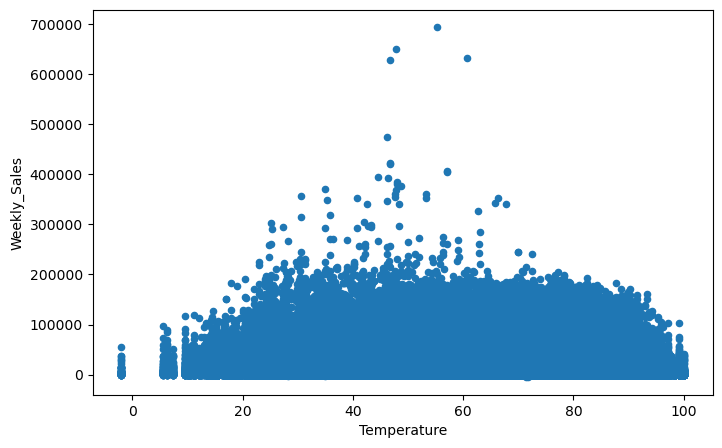

In [64]:
final_merge.plot.scatter(
    x="Temperature",
    y="Weekly_Sales",
    figsize=(8,5)
)

In [66]:
correlation = final_merge.select_dtypes(include="number").corr()

correlation

,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
Store,1.00,0.02,-0.09,-0.18,-0.05,0.07,-0.12,-0.04,-0.03,-0.01,-0.03,-0.21,0.21
Dept,0.02,1.00,0.15,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.01,0.01
Weekly_Sales,-0.09,0.15,1.00,0.24,-0.00,-0.00,0.09,0.02,0.06,0.05,0.09,-0.02,-0.03
Size,-0.18,-0.00,0.24,1.00,-0.06,0.00,0.35,0.11,0.05,0.17,0.30,-0.00,-0.07
Temperature,-0.05,0.00,-0.00,-0.06,1.00,0.14,-0.04,-0.32,-0.10,-0.06,-0.02,0.18,0.10
Fuel_Price,0.07,0.00,-0.00,0.00,0.14,1.00,0.06,-0.22,-0.10,-0.04,-0.13,-0.16,-0.03
MarkDown1,-0.12,-0.00,0.09,0.35,-0.04,0.06,1.00,0.02,-0.11,0.82,0.16,-0.06,0.05
MarkDown2,-0.04,0.00,0.02,0.11,-0.32,-0.22,0.02,1.00,-0.05,-0.01,-0.01,-0.04,0.02
MarkDown3,-0.03,0.00,0.06,0.05,-0.10,-0.10,-0.11,-0.05,1.00,-0.07,-0.03,-0.02,0.01
MarkDown4,-0.01,0.00,0.05,0.17,-0.06,-0.04,0.82,-0.01,-0.07,1.00,0.11,-0.05,0.02


In [ ]:
# 1. Walmart dataset contains 45 unique stores.
# 2. There are 81 unique departments.
 # 3. Stores are categorized into Type A, B and C.
# 4. Weekly Sales is the target variable.
# 5. Weekly Sales distribution is right-skewed.
# 6. Store 20 generated the highest total sales.
# 7. MarkDown columns contain significant missing values.
# 8. The dataset contains promotional, economic and weather-related features.
# 9. Date column requires feature engineering before modeling.
# 10. The merged dataset is ready for the Data Cleaning phase.